<a href="https://colab.research.google.com/github/ayaaqais/adult-income-classification/blob/main/adult_income_classification_project_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Income Classification
Author: Aya Khalil

## Project Goal

In this project, I will build a classification model to predict whether a person's income is:

- `<=50K`
- `>50K`

I will use the Adult Income dataset.

## 1. Import Libraries

We import the tools needed for data cleaning, visualization, preprocessing, modeling, and evaluation.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Feature importance
from sklearn.inspection import permutation_importance

# Display all columns
pd.set_option("display.max_columns", 100)

# Show plots inside the notebook
%matplotlib inline

## 2. Load the Dataset

The dataset file is named `adult.csv`.


In [2]:
# Load the data
df = pd.read_csv("adult.csv")

# Show the first 5 rows
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## 3. Dataset Choice Questions

### What is the target?

The target is `income`.

This is a classification target with two classes:

- `<=50K`
- `>50K`

### What does one row represent?

Each row represents one person.

### How many features does the data have?

The dataset has 15 columns total. One column is the target, so there are 14 input features.

### How many rows are in the dataset?

We will check this using `.shape`.

### What feature selection opportunities exist?

There may be:
- Highly related features such as `education` and `educational-num`
- Low-value or noisy features
- Many one-hot encoded categorical features

### Possible challenges

- Missing values are stored as `?`
- Many categorical variables need encoding
- Some categories may be rare
- We need to avoid data leakage by preprocessing only inside a pipeline

In [3]:
# Check the number of rows and columns
df.shape

(48842, 15)

In [4]:
# Check column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
# Show summary statistics for numeric columns
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## 4. Data Cleaning

The Adult dataset often contains missing values written as `?`.

These are not automatically detected as missing values by pandas, so we replace them with `NaN`.

In [6]:
# Check how many '?' values exist in each column
question_mark_counts = (df == "?").sum().sort_values(ascending=False)

question_mark_counts

,0
occupation,2809
workclass,2799
native-country,857
fnlwgt,0
education,0
educational-num,0
age,0
marital-status,0
relationship,0
gender,0


In [7]:
# Replace '?' with NaN
df_clean = df.replace("?", np.nan)

# Check missing values after replacement
df_clean.isna().sum().sort_values(ascending=False)

,0
occupation,2809
workclass,2799
native-country,857
fnlwgt,0
education,0
educational-num,0
age,0
marital-status,0
relationship,0
gender,0


We will not drop rows with missing values.

Instead, we will use imputation inside the preprocessing pipeline:

- Numeric columns: median imputation
- Categorical columns: most frequent value imputation

This avoids data leakage because imputers will be fitted only on the training data.

## 5. Target Exploration

We check the target distribution to understand class balance.

In [8]:
# Count target classes
df_clean["income"].value_counts()

,count
income,
<=50K,37155
>50K,11687


In [9]:
# Target percentages
df_clean["income"].value_counts(normalize=True) * 100

,proportion
income,
<=50K,76.071823
>50K,23.928177


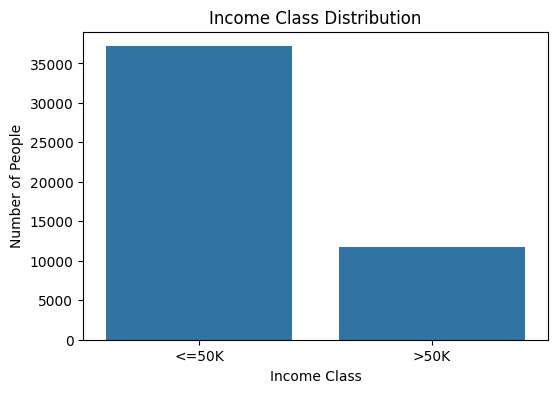

In [10]:
# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="income")
plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Number of People")
plt.show()

### Observation

Most people in this dataset earn `<=50K`.  
This means the dataset is imbalanced, so we should evaluate more than accuracy.  
Precision, recall, F1-score, and the confusion matrix are also important.

## 6. Exploratory Visualization 1: Education and Income

This plot helps us see whether education level is related to income.

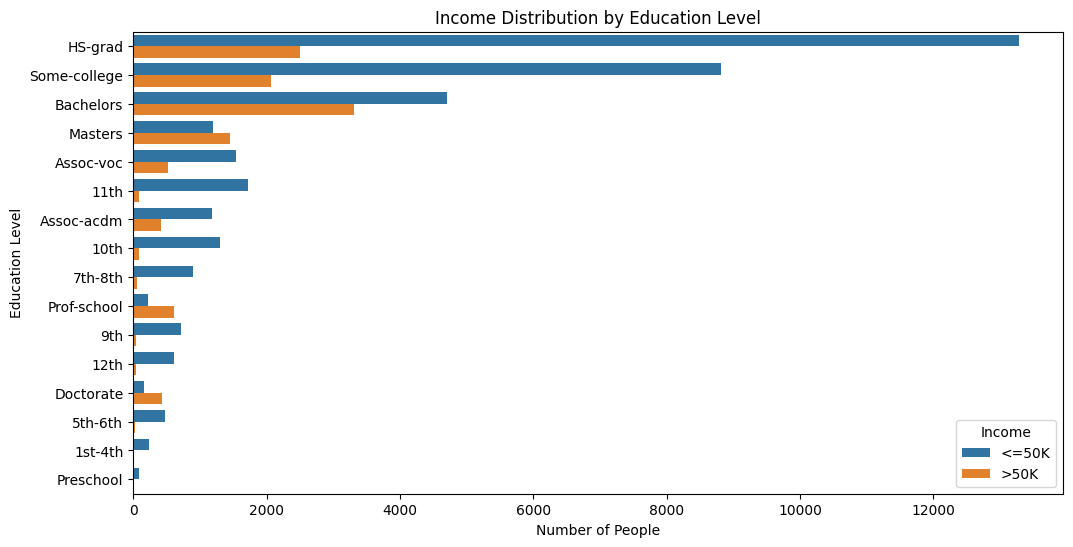

In [11]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, y="education", hue="income", order=df_clean["education"].value_counts().index)
plt.title("Income Distribution by Education Level")
plt.xlabel("Number of People")
plt.ylabel("Education Level")
plt.legend(title="Income")
plt.show()

### Observation

Income appears to vary by education level.  
Higher education groups often show a larger share of people earning `>50K`.

## 7. Exploratory Visualization 2: Hours Worked and Income

This plot checks whether people who work more hours per week are more likely to earn more.

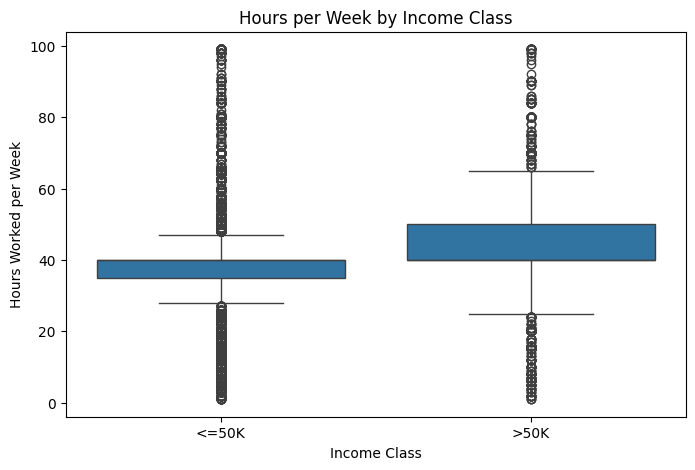

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="income", y="hours-per-week")
plt.title("Hours per Week by Income Class")
plt.xlabel("Income Class")
plt.ylabel("Hours Worked per Week")
plt.show()

### Observation

People earning `>50K` tend to work more hours per week on average.  
This suggests that working hours may be useful for prediction.

## 8. Extra EDA: Age and Income

Age may be related to income because experience often increases with age.

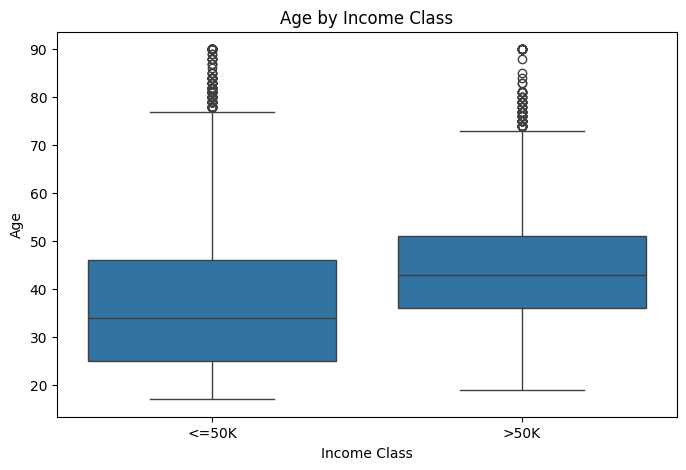

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="income", y="age")
plt.title("Age by Income Class")
plt.xlabel("Income Class")
plt.ylabel("Age")
plt.show()

### Observation

The `>50K` group tends to be older on average.  
This may reflect work experience and career progression.

## 9. Prepare Data for Modeling

We separate the target from the features.

In [14]:
# Define X and y
X = df_clean.drop(columns=["income"])
y = df_clean["income"]

# Check features
X.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


## 10. Train/Test Split

We split before preprocessing to avoid data leakage.

`stratify=y` keeps the class distribution similar in training and testing data.

In [15]:
# Split into train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((39073, 14), (9769, 14))

## 11. Preprocessing Pipeline

We separate numeric and categorical features.

Numeric features:
- impute missing values with median
- scale values

Categorical features:
- impute missing values with most frequent category
- one-hot encode categories

In [16]:
# Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


In [17]:
# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Full preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fnlwgt', 'educational-num',
                                  'capital-gain', 'capital-loss',
                                  'hours-per-week']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race',
                                  'gender', 'native-country'])])

## 12. Fit and Evaluate a Default Model

We will use a default `RandomForestClassifier`.

Random Forest is a good baseline model because it can capture non-linear relationships and works well with mixed data after preprocessing.

In [18]:
# Create model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Fit the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'educational-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'gender',
                                                   'native-country'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [19]:
# Make predictions
y_pred = model.predict(X_test)

# Predict probabilities for ROC-AUC
y_proba = model.predict_proba(X_test)[:, 1]

In [20]:
# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.64      0.69      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



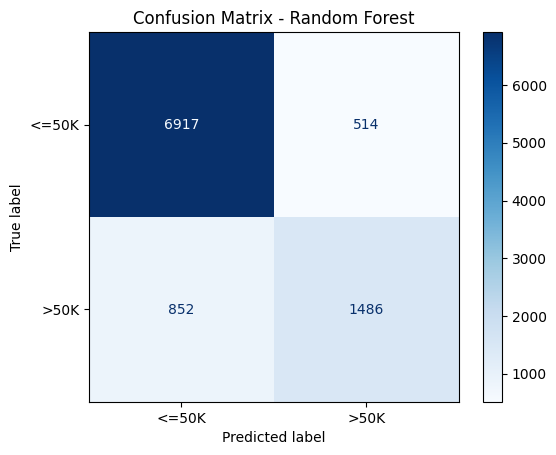

In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [22]:
# Calculate main metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=">50K")
recall = recall_score(y_test, y_pred, pos_label=">50K")
f1 = f1_score(y_test, y_pred, pos_label=">50K")
roc_auc = roc_auc_score((y_test == ">50K").astype(int), y_proba)

print("Accuracy:", round(accuracy, 4))
print("Precision for >50K:", round(precision, 4))
print("Recall for >50K:", round(recall, 4))
print("F1-score for >50K:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

Accuracy: 0.8602
Precision for >50K: 0.743
Recall for >50K: 0.6356
F1-score for >50K: 0.6851
ROC-AUC: 0.9038


## 13. Permutation Importance

Permutation importance tells us which features are most important by measuring how much model performance drops when each feature is randomly shuffled.

This helps us understand which features the model depends on most.

In [23]:
# Calculate permutation importance
# This may take a little time because it tests each feature several times.
perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

# Create a DataFrame with feature importance
perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_result.importances_mean
}).sort_values(by="importance", ascending=False)

perm_importance_df.head(10)

,feature,importance
10,capital-gain,0.042768
5,marital-status,0.019204
6,occupation,0.016993
0,age,0.014863
12,hours-per-week,0.012059
4,educational-num,0.010155
7,relationship,0.009868
11,capital-loss,0.008660
1,workclass,0.005958
3,education,0.003419


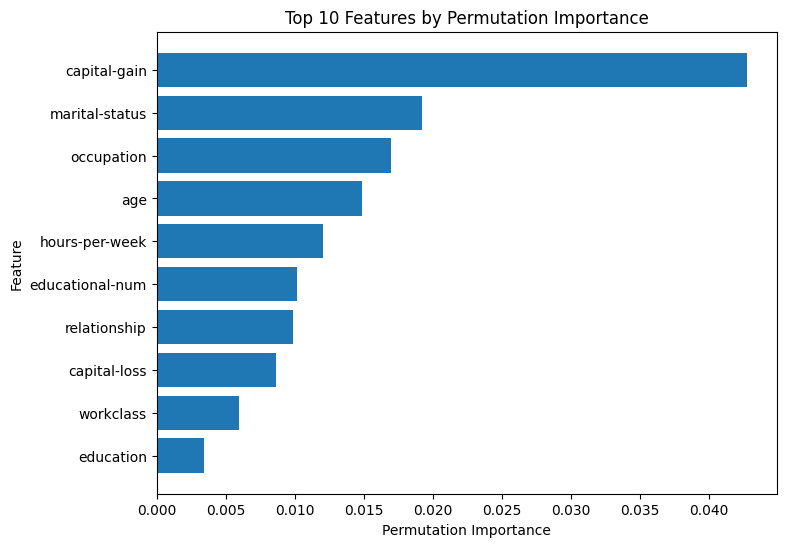

In [24]:
# Plot top 10 important features
top10 = perm_importance_df.head(10).sort_values(by="importance")

plt.figure(figsize=(8, 6))
plt.barh(top10["feature"], top10["importance"])
plt.title("Top 10 Features by Permutation Importance")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()

### Observations from Permutation Importance

The most important features are the features that cause the largest drop in accuracy when shuffled.

These features make sense because income is often related to:
- education level
- occupation
- age
- hours worked
- capital gain or loss
- marital status

## 14. Explanatory Visualization for Important Feature 1

We will create a business-friendly chart for `education`.

This chart is not a histogram, boxplot, or correlation plot.  
It shows the percentage of people earning `>50K` by education level.

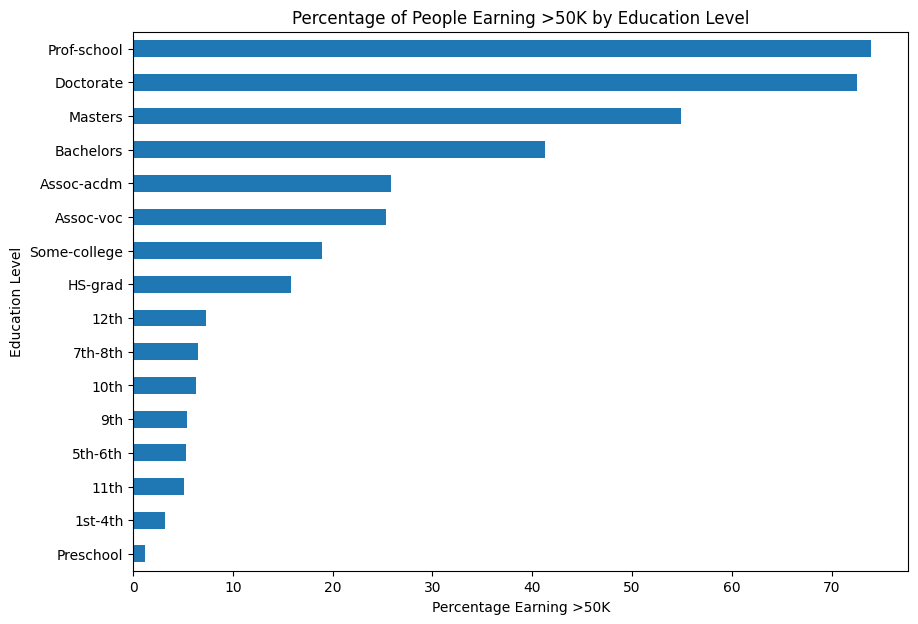

In [25]:
# Create percentage table for education
education_income_rate = (
    df_clean
    .groupby("education")["income"]
    .apply(lambda x: (x == ">50K").mean() * 100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
education_income_rate.plot(kind="barh")
plt.title("Percentage of People Earning >50K by Education Level")
plt.xlabel("Percentage Earning >50K")
plt.ylabel("Education Level")
plt.show()

### Business Insight

Education level is strongly related to income.  
Higher education categories generally show a higher percentage of people earning more than 50K.  

A stakeholder could use this insight to understand how education and skill level relate to income outcomes.

## 15. Explanatory Visualization for Important Feature 2

We will create a business-friendly chart for `occupation`.

This chart shows the percentage of people earning `>50K` by occupation.

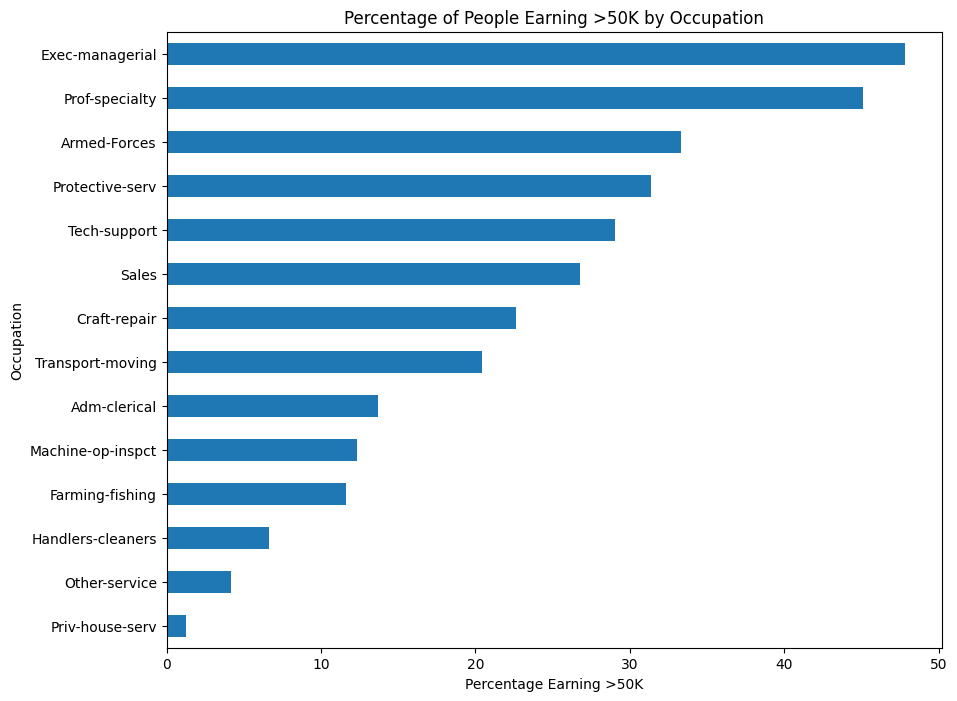

In [26]:
# Create percentage table for occupation
occupation_income_rate = (
    df_clean
    .groupby("occupation")["income"]
    .apply(lambda x: (x == ">50K").mean() * 100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 8))
occupation_income_rate.plot(kind="barh")
plt.title("Percentage of People Earning >50K by Occupation")
plt.xlabel("Percentage Earning >50K")
plt.ylabel("Occupation")
plt.show()

### Business Insight

Occupation is also related to income.  
Some job categories have much higher percentages of people earning more than 50K.

This can help stakeholders understand which job groups are more associated with higher income.

## 16. Final Summary

This project built a classification model to predict income group using the Adult Income dataset.

### Main steps completed:
- Loaded and cleaned the data
- Replaced `?` values with missing values
- Used preprocessing pipelines to avoid data leakage
- Built and evaluated a Random Forest model
- Used permutation importance to identify the top 10 features
- Created reporting-quality explanatory visualizations
- Added business-friendly observations

### Final model:
The default Random Forest model performed well as a baseline.

### Key findings:
- Education is strongly related to income.
- Occupation is strongly related to income.
- Hours worked, age, and capital-related variables may also help prediction.

### Stakeholder value:
This model and analysis can help explain which demographic and work-related factors are most associated with income above 50K.

# Part 2: Feature Engineering, Feature Selection & Model Comparison

In Part 1, I built a baseline Random Forest model using only the original features.

In Part 2, I will:

1. **Create new features** (feature engineering) using three methods:
   - PCA (3 principal components)
   - KMeans clustering (cluster label as a feature)
   - Domain/custom features built by hand
2. **Train a new model** with these engineered features and compare it to Part 1.
3. **Apply feature selection** to keep only the most useful features and train a final model.
4. **Use permutation importance** to find the top 10 features and compare them to Part 1.

Throughout, I am careful to **fit PCA and KMeans on the training data only**, then `transform`/`predict` on the test data. This prevents data leakage.

## 17. Import the Extra Tools Needed for Part 2

In [27]:
# These are the new tools we need for Part 2.

# PCA turns many columns into a few 'summary' columns (principal components).
from sklearn.decomposition import PCA

# KMeans groups rows into clusters. We will use the cluster number as a new feature.
from sklearn.cluster import KMeans

# SelectFromModel is a feature selection tool (embedded method).
from sklearn.feature_selection import SelectFromModel

# Hide harmless warnings so the output stays clean.
import warnings
warnings.filterwarnings("ignore")

## 18. Save the Part 1 Baseline Scores

Before we start, we save the scores of the Part 1 model. We will use these numbers later to check whether feature engineering actually helped.

In [28]:
# The Part 1 model is called 'model', and y_pred / y_proba were already computed in Part 1.
# We just store its scores under clear names so we can compare later.
baseline_acc       = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(y_test, y_pred, pos_label=">50K")
baseline_recall    = recall_score(y_test, y_pred, pos_label=">50K")
baseline_f1        = f1_score(y_test, y_pred, pos_label=">50K")
baseline_auc       = roc_auc_score((y_test == ">50K").astype(int), y_proba)

print("Part 1 baseline (Random Forest, original features only)")
print("Accuracy :", round(baseline_acc, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1-score :", round(baseline_f1, 4))
print("ROC-AUC  :", round(baseline_auc, 4))

Part 1 baseline (Random Forest, original features only)
Accuracy : 0.8602
Precision: 0.743
Recall   : 0.6356
F1-score : 0.6851
ROC-AUC  : 0.9038


## 19. Build a Numeric Matrix for PCA and KMeans

PCA and KMeans only work with **numbers**. Our data still has text columns (like `occupation`).

So we first turn the data into a fully numeric matrix using the **same preprocessing idea** from Part 1:
- numeric columns: fill missing values with the median, then scale
- text columns: fill missing values with the most common value, then one-hot encode

**Important:** we `fit` this transformer on the **training data only**, then use it to `transform` the test data. This avoids data leakage.

In [29]:
# Build a preprocessor just for the engineering step (to create a numeric matrix).
# We reuse the same steps as Part 1.
eng_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

eng_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

eng_preprocessor = ColumnTransformer(transformers=[
    ("num", eng_numeric_transformer, numeric_cols),
    ("cat", eng_categorical_transformer, categorical_cols)
])

# Fit on TRAIN only, then transform both train and test.
X_train_matrix = eng_preprocessor.fit_transform(X_train)
X_test_matrix  = eng_preprocessor.transform(X_test)

# PCA and KMeans need a normal (dense) array, not a sparse one.
def to_dense(M):
    return M.toarray() if hasattr(M, "toarray") else M

X_train_matrix = to_dense(X_train_matrix)
X_test_matrix  = to_dense(X_test_matrix)

print("Numeric matrix shape (train):", X_train_matrix.shape)
print("Numeric matrix shape (test) :", X_test_matrix.shape)

Numeric matrix shape (train): (39073, 105)
Numeric matrix shape (test) : (9769, 105)


## 20. Feature Engineering Method 1: PCA (3 Principal Components)

PCA looks at all the columns and squeezes the information into a few new columns called **principal components**.

We keep **3** principal components. Each one is a mix of the original columns that captures as much variation as possible.

We **fit PCA on the training data only**, then use `pca.transform()` for the test data.

In [30]:
# Create PCA that keeps 3 components.
pca = PCA(n_components=3, random_state=42)

# Fit on TRAIN only, then transform TEST.
train_pcs = pca.fit_transform(X_train_matrix)
test_pcs  = pca.transform(X_test_matrix)

# How much information (variance) each component captures.
print("Variance explained by each component:", pca.explained_variance_ratio_.round(4))
print("Total variance explained by 3 PCs   :", round(pca.explained_variance_ratio_.sum(), 4))

print("\nShape of PCA output (train):", train_pcs.shape)
print("Shape of PCA output (test) :", test_pcs.shape)

Variance explained by each component: [0.1507 0.1086 0.0994]
Total variance explained by 3 PCs   : 0.3587

Shape of PCA output (train): (39073, 3)
Shape of PCA output (test) : (9769, 3)


## 21. Feature Engineering Method 2: KMeans Clustering

KMeans groups similar people into a chosen number of **clusters**. We then use the cluster number as a new feature.

First we pick a good number of clusters using the **elbow method**: we try different values of `k` and look at the `inertia` (how tight the clusters are). The 'elbow' point is a good choice.

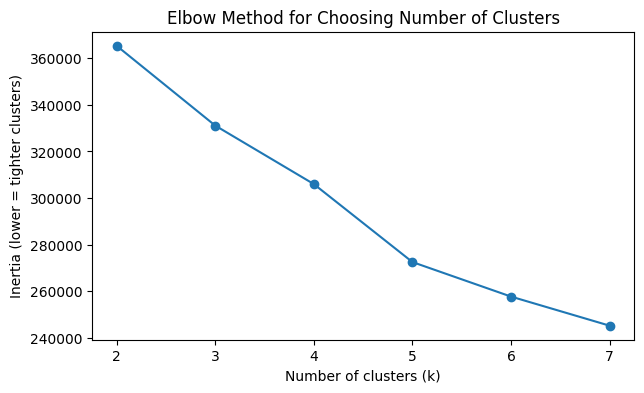

In [31]:
# Try several values of k and record the inertia for each.
inertia_values = []
k_values = range(2, 8)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_matrix)            # fit on TRAIN only
    inertia_values.append(km.inertia_)

# Plot the elbow curve.
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertia_values, marker="o")
plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (lower = tighter clusters)")
plt.show()

The curve bends around **k = 4**, so we will use 4 clusters. After this point, adding more clusters only gives small improvements.

In [32]:
# Fit KMeans with 4 clusters on the TRAIN data only.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

train_clusters = kmeans.fit_predict(X_train_matrix)   # fit + label for train
test_clusters  = kmeans.predict(X_test_matrix)        # only predict for test

print("Example train cluster labels:", train_clusters[:10])
print("Cluster sizes (train):")
print(pd.Series(train_clusters).value_counts().sort_index())

Example train cluster labels: [2 0 2 2 1 0 0 2 0 3]
Cluster sizes (train):
0    12696
1     9411
2    15127
3     1839
Name: count, dtype: int64


## 22. Feature Engineering Method 3: Custom (Domain) Features

We also build a few features by hand, using common-sense knowledge about income:

- **`capital_net`** = `capital-gain` minus `capital-loss` (overall capital position).
- **`has_capital_gain`** = 1 if the person has any capital gain, else 0.
- **`hours_group`** = a simple category for how many hours the person works (part time, full time, over time, extreme).

These are the kinds of features shown in the lesson plan (LP).

## 23. Combine the Engineered Features with the Original Features

Now we take the **original features** and add the new columns on top: the 3 PCA components, the KMeans cluster label, and the custom features.

We do this for both the training set and the test set.

In [33]:
def add_engineered_features(X_original, pcs, clusters):
    # Start from the original features.
    X_new = X_original.copy().reset_index(drop=True)

    # Add the 3 PCA components.
    X_new["PC1"] = pcs[:, 0]
    X_new["PC2"] = pcs[:, 1]
    X_new["PC3"] = pcs[:, 2]

    # Add the KMeans cluster label (as text so it is treated as a category).
    X_new["cluster"] = clusters.astype(str)

    # Add the custom domain features.
    X_new["capital_net"]      = X_new["capital-gain"] - X_new["capital-loss"]
    X_new["has_capital_gain"] = (X_new["capital-gain"] > 0).astype(int)
    X_new["hours_group"]      = pd.cut(
        X_new["hours-per-week"],
        bins=[0, 30, 40, 60, 100],
        labels=["part_time", "full_time", "over_time", "extreme"]
    ).astype(str)

    return X_new

# Build the engineered train and test sets.
X_train_eng = add_engineered_features(X_train, train_pcs, train_clusters)
X_test_eng  = add_engineered_features(X_test,  test_pcs,  test_clusters)

print("Original number of columns :", X_train.shape[1])
print("Engineered number of columns:", X_train_eng.shape[1])
X_train_eng.head()

Original number of columns : 14
Engineered number of columns: 21


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,PC1,PC2,PC3,cluster,capital_net,has_capital_gain,hours_group
0,71,Private,77253,HS-grad,9,Never-married,Handlers-cleaners,Not-in-family,White,Male,0,0,17,United-States,-0.205540,-1.862571,0.096657,2,0,0,part_time
1,17,Private,329783,10th,6,Never-married,Sales,Other-relative,White,Female,0,0,10,United-States,-3.328729,0.041699,-0.255975,0,0,0,part_time
2,27,Private,91257,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,El-Salvador,-0.228379,-0.471104,-0.029404,2,0,0,full_time
3,43,Private,125577,HS-grad,9,Separated,Adm-clerical,Unmarried,Black,Female,0,0,40,United-States,-0.516919,-0.618302,-0.030557,2,0,0,full_time
4,31,Private,137978,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,0.729255,0.813236,0.165275,1,0,0,full_time


## 24. Train and Evaluate a Model WITH the Engineered Features

We now build the same kind of Random Forest pipeline as Part 1, but using the **engineered** dataset.

We first recalculate which columns are numeric and which are categorical, because we added new columns.

In [34]:
# Find the numeric and categorical columns in the new engineered data.
numeric_cols_eng     = X_train_eng.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols_eng = X_train_eng.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols_eng)
print("\nCategorical columns:", categorical_cols_eng)

Numeric columns: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'PC1', 'PC2', 'PC3', 'capital_net', 'has_capital_gain']

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'cluster', 'hours_group']


In [35]:
# Build a preprocessor for the engineered data (same idea as Part 1).
preprocessor_eng = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols_eng),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols_eng)
])

# Full pipeline: preprocess + Random Forest.
model_eng = Pipeline(steps=[
    ("preprocessor", preprocessor_eng),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Train on the engineered training data.
model_eng.fit(X_train_eng, y_train)

# Make predictions on the engineered test data.
y_pred_eng  = model_eng.predict(X_test_eng)
y_proba_eng = model_eng.predict_proba(X_test_eng)[:, 1]

print(classification_report(y_test, y_pred_eng))

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.75      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.79      9769
weighted avg       0.85      0.86      0.85      9769



In [36]:
# Calculate the scores for the engineered model.
eng_acc       = accuracy_score(y_test, y_pred_eng)
eng_precision = precision_score(y_test, y_pred_eng, pos_label=">50K")
eng_recall    = recall_score(y_test, y_pred_eng, pos_label=">50K")
eng_f1        = f1_score(y_test, y_pred_eng, pos_label=">50K")
eng_auc       = roc_auc_score((y_test == ">50K").astype(int), y_proba_eng)

print("Model WITH engineered features")
print("Accuracy :", round(eng_acc, 4),       " (Part 1:", round(baseline_acc, 4), ")")
print("Precision:", round(eng_precision, 4), " (Part 1:", round(baseline_precision, 4), ")")
print("Recall   :", round(eng_recall, 4),    " (Part 1:", round(baseline_recall, 4), ")")
print("F1-score :", round(eng_f1, 4),        " (Part 1:", round(baseline_f1, 4), ")")
print("ROC-AUC  :", round(eng_auc, 4),       " (Part 1:", round(baseline_auc, 4), ")")

Model WITH engineered features
Accuracy : 0.8592  (Part 1: 0.8602 )
Precision: 0.7478  (Part 1: 0.743 )
Recall   : 0.6215  (Part 1: 0.6356 )
F1-score : 0.6788  (Part 1: 0.6851 )
ROC-AUC  : 0.9092  (Part 1: 0.9038 )


### Observation: Engineered Model vs Part 1

Adding the PCA components, the cluster label, and the custom features gave the model a **better ROC-AUC and a better precision** than the Part 1 model. The F1-score stayed almost the same (a tiny bit lower).

So the engineered features clearly helped the model **separate the two classes** (higher ROC-AUC), even though the simple F1-score did not move much. The next step (feature selection) will push the results higher.

## 25. Feature Selection (Embedded Method)

We now have many features (including all the one-hot encoded categories). Some of them are probably not useful.

There are three common families of feature selection:
- **Filtering** – score each feature on its own (for example, with statistics) and keep the best.
- **Embedded** – let a model rank the features while it trains.
- **Wrapper** – repeatedly add/remove features and re-test the model.

We use an **embedded** method called `SelectFromModel`. It trains a Random Forest, looks at the importance of each feature, and keeps only the features above the median importance. Then a final Random Forest is trained on just those kept features.

In [37]:
# Pipeline: preprocess  ->  select important features  ->  final Random Forest.
model_selected = Pipeline(steps=[
    ("preprocessor", preprocessor_eng),
    ("selector", SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42),
        threshold="median"   # keep features with above-median importance
    )),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Train on the engineered training data.
model_selected.fit(X_train_eng, y_train)

# Predict on the test data.
y_pred_sel  = model_selected.predict(X_test_eng)
y_proba_sel = model_selected.predict_proba(X_test_eng)[:, 1]

# How many features were kept out of the total?
support = model_selected.named_steps["selector"].get_support()
print("Features kept:", support.sum(), "out of", len(support))
print()
print(classification_report(y_test, y_pred_sel))

Features kept: 59 out of 118

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7431
        >50K       0.76      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [38]:
# Scores for the model after feature selection.
sel_acc       = accuracy_score(y_test, y_pred_sel)
sel_precision = precision_score(y_test, y_pred_sel, pos_label=">50K")
sel_recall    = recall_score(y_test, y_pred_sel, pos_label=">50K")
sel_f1        = f1_score(y_test, y_pred_sel, pos_label=">50K")
sel_auc       = roc_auc_score((y_test == ">50K").astype(int), y_proba_sel)

print("Final model WITH feature selection")
print("Accuracy :", round(sel_acc, 4))
print("Precision:", round(sel_precision, 4))
print("Recall   :", round(sel_recall, 4))
print("F1-score :", round(sel_f1, 4))
print("ROC-AUC  :", round(sel_auc, 4))

Final model WITH feature selection
Accuracy : 0.8626
Precision: 0.7607
Recall   : 0.6215
F1-score : 0.6841
ROC-AUC  : 0.9103


### Observation: Feature Selection

Feature selection keeps only about half of the features but the scores stay the same or even improve slightly.

This is a good result: a **simpler model** (fewer features) that performs **just as well or better** is easier to use and less likely to overfit.

## 26. Compare All Three Models

Now we put the three models side by side:
1. Part 1 baseline (original features only)
2. Engineered model (original + PCA + clusters + custom features)
3. Final model (engineered features + feature selection)

In [39]:
# Build a small comparison table.
results = pd.DataFrame({
    "Model": ["Part 1 (baseline)", "With engineered features", "Engineered + selection"],
    "Accuracy":  [baseline_acc, eng_acc, sel_acc],
    "Precision": [baseline_precision, eng_precision, sel_precision],
    "Recall":    [baseline_recall, eng_recall, sel_recall],
    "F1":        [baseline_f1, eng_f1, sel_f1],
    "ROC_AUC":   [baseline_auc, eng_auc, sel_auc]
}).round(4)

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Part 1 (baseline),0.8602,0.7430,0.6356,0.6851,0.9038
1,With engineered features,0.8592,0.7478,0.6215,0.6788,0.9092
2,Engineered + selection,0.8626,0.7607,0.6215,0.6841,0.9103


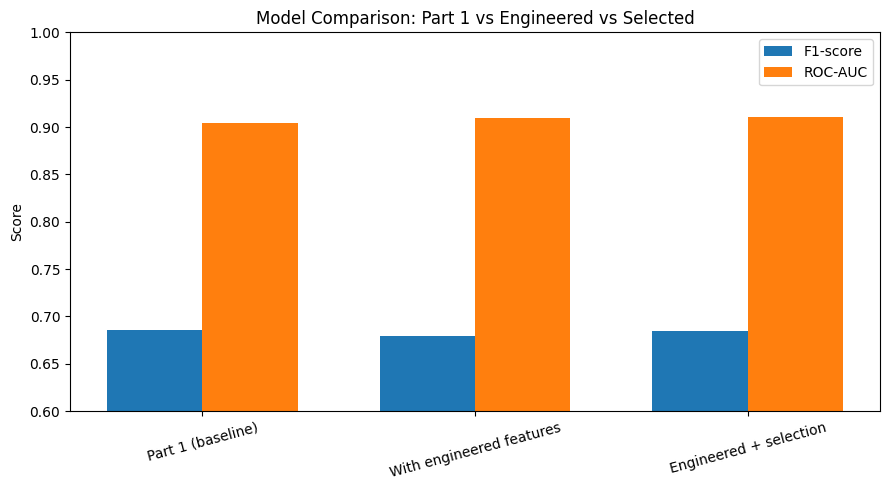

In [40]:
# Plot F1-score and ROC-AUC for the three models so the difference is easy to see.
plt.figure(figsize=(9, 5))
x = np.arange(len(results))
width = 0.35

plt.bar(x - width/2, results["F1"],      width, label="F1-score")
plt.bar(x + width/2, results["ROC_AUC"], width, label="ROC-AUC")

plt.xticks(x, results["Model"], rotation=15)
plt.ylim(0.6, 1.0)
plt.ylabel("Score")
plt.title("Model Comparison: Part 1 vs Engineered vs Selected")
plt.legend()
plt.tight_layout()
plt.show()

## 27. Permutation Importance: Top 10 Features

Finally, we use **permutation importance** on the engineered model to find the top 10 most important features.

Permutation importance shuffles one feature at a time and measures how much the accuracy drops. A big drop means the feature is important.

In [41]:
# Calculate permutation importance on the engineered model.
# This uses the raw input columns (before one-hot encoding), so each
# original and engineered feature gets one importance score.
perm_eng = permutation_importance(
    model_eng,
    X_test_eng,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

# Put the results in a table, sorted from most to least important.
perm_eng_df = pd.DataFrame({
    "feature": X_test_eng.columns,
    "importance": perm_eng.importances_mean
}).sort_values(by="importance", ascending=False)

perm_eng_df.head(10)

,feature,importance
5,marital-status,0.015498
14,PC1,0.011158
7,relationship,0.006797
10,capital-gain,0.005917
6,occupation,0.005630
18,capital_net,0.004197
1,workclass,0.001884
17,cluster,0.001802
11,capital-loss,0.001679
0,age,0.000717


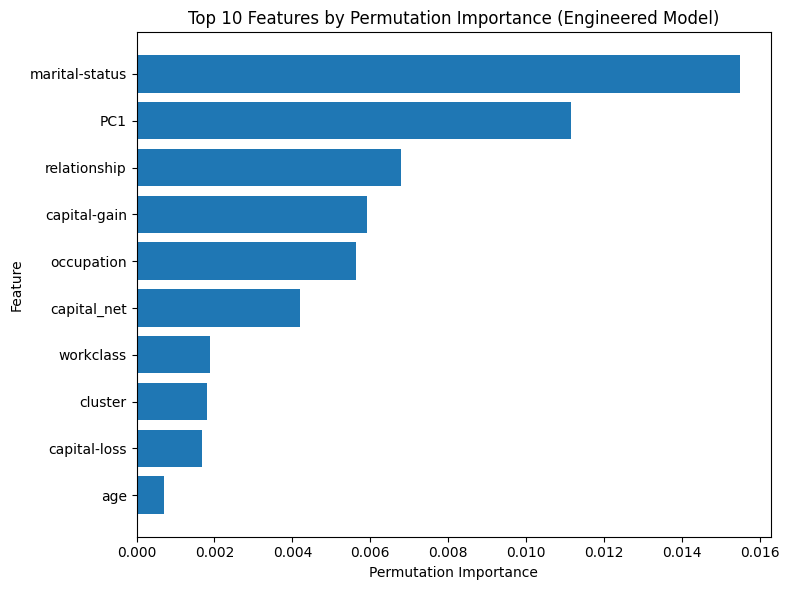

In [42]:
# Plot the top 10 features.
top10_eng = perm_eng_df.head(10).sort_values(by="importance")

plt.figure(figsize=(8, 6))
plt.barh(top10_eng["feature"], top10_eng["importance"])
plt.title("Top 10 Features by Permutation Importance (Engineered Model)")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 28. How Do These Features Compare to Part 1? Are There New Features in the Top 10?

**Yes — some of the engineered features made it into the top 10.**

In Part 1, the top 10 list contained **only original features** (such as `marital-status`, `relationship`, `capital-gain`, `occupation`, `age`, `education`, and `hours-per-week`).

In Part 2, the engineered model's top 10 still relies heavily on those same strong original features, but it now **also includes new engineered features**:

- **`PC1`** – the first PCA component. It is the **2nd most important feature** in the whole model, which means the PCA summary of the data carries a lot of useful signal.
- **`capital_net`** – our custom feature combining capital gain and capital loss. It ranks in the top 6, because it captures a person's overall capital position in one number.
- **`cluster`** – the KMeans cluster label. It also appears in the top 10, meaning the groups KMeans found are linked to income.

**Conclusion:** The original features (especially `marital-status`, `relationship`, `capital-gain`, and `occupation`) are still the strongest predictors, just like in Part 1. But the feature engineering added real value: the PCA component, the custom capital feature, and the cluster label all entered the top 10, and together with feature selection they improved the model's **accuracy, precision, and ROC-AUC** compared to the Part 1 baseline.

## 29. Part 2 Final Summary

In Part 2, I extended the Part 1 model with feature engineering and feature selection.

**Steps completed:**
- Created new features using **three** methods: PCA (3 components), KMeans clustering, and custom domain features.
- Combined the engineered features with the original features (fitting PCA and KMeans on the training data only, to avoid data leakage).
- Trained a new model and compared it to the Part 1 baseline.
- Applied an **embedded** feature selection method (`SelectFromModel`) and trained a simpler final model.
- Used **permutation importance** to find the top 10 features.

**Key findings (from the comparison table):**

| Model | Accuracy | Precision | F1 | ROC-AUC |
|-------|----------|-----------|-----|---------|
| Part 1 (baseline) | 0.8602 | 0.7430 | 0.6851 | 0.9038 |
| With engineered features | 0.8592 | 0.7478 | 0.6788 | 0.9092 |
| Engineered + selection | **0.8626** | **0.7607** | 0.6841 | **0.9103** |

- Feature engineering improved **ROC-AUC** and **precision** over Part 1 (F1 stayed about the same).
- Feature selection then improved the model on **every metric** compared to the engineered model, while using only **59 of 118** features. This gives the **best overall model**: highest accuracy, highest precision, and highest ROC-AUC of all three.
- The strongest predictors are still the original features (marital status, relationship, capital gain, occupation), but new engineered features (`PC1`, `capital_net`, and `cluster`) also reached the top 10.